# YOLO inference-time prediction

**Цель:** по параметрам железа + архитектуры YOLO + размера/батча входа предсказать время инференса (`predicting_times`).

**План:**
1. Загрузка и первичный осмотр данных.
2. Препроцессинг: выкидываем `model_param_dict`, дубли колонок, приводим `Unknown` к NaN, генерим производные фичи, логарифмируем таргет.
3. EDA: распределение таргета, время по устройствам/моделям, корреляции, scatter work vs time.
4. Валидация через **GroupKFold** по `(cpu_name, gpu_name)` — чтобы не текла информация об уже виденном железе.
5. Сравнение 6 моделей: **CatBoost, LightGBM, XGBoost, RandomForest, KNN, LinearRegression**.
6. Feature importance у tree-моделей.
7. Box-plot ошибок на held-out сплите.
8. Сравнение унифицированной модели vs две специализированные (GPU/CPU) — проверяем, выигрывает ли сплит.

In [98]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import catboost as cb
import lightgbm as lgb
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 60)

## 1. Загрузка и первичный осмотр

In [99]:
raw = pd.read_csv('data_base.csv')
print('shape:', raw.shape)
raw.head(3)

shape: (7200, 35)


,cpu_name,gpu_name,gpu_memory,used_gpu,ram_memory,model_name,model_param_dict,num_all_params,model_img_size,image_batch_size,predicting_times,Processor,Frequency (MHz),Max Frequency (MHz),Cores,Threads,l1_cache_size (KB),l1_instruction_cache_size (KB),l2_cache_size_per_core (KB),l2_cache_size (KB),l3_cache_size (MB),SMP Supported,GPU Name,Compute Capability (cuda version),Number of SMs,Cores per SM,Total CUDA Cores,Number of Tensor Cores,Clock Rate (GHz) boost,FP32 FLOPS (TFLOPS),TF32 FLOPS (TFLOPS),FP16 FLOPS (TFLOPS),BF16 FLOPS (TFLOPS),FP64 FLOPS (GFLOPS),FP64 TENSOR FLOPS (TFLOPS)
0,AMD Ryzen 7 5700X 8-Core Processor,NVIDIA GeForce RTX 3060,12.0,False,32,yolov5nu.pt,"{'model.0.conv.weight': 1728, 'model.0.bn.weig...",2654816,160,1,0.081995,AMD Ryzen 7 5700X 8-Core Processor,3401.0,3401.0,8,16,Unknown,Unknown,524.288,4194.304,33.554432,True,NVIDIA GeForce RTX 3060,8.6,28,128,3584,112,1.837,13.167616,0.0,13.167616,0.0,205.744,0.0
1,AMD Ryzen 7 5700X 8-Core Processor,NVIDIA GeForce RTX 3060,12.0,False,32,yolov5nu.pt,"{'model.0.conv.weight': 1728, 'model.0.bn.weig...",2654816,320,1,0.044995,AMD Ryzen 7 5700X 8-Core Processor,3401.0,3401.0,8,16,Unknown,Unknown,524.288,4194.304,33.554432,True,NVIDIA GeForce RTX 3060,8.6,28,128,3584,112,1.837,13.167616,0.0,13.167616,0.0,205.744,0.0
2,AMD Ryzen 7 5700X 8-Core Processor,NVIDIA GeForce RTX 3060,12.0,False,32,yolov5nu.pt,"{'model.0.conv.weight': 1728, 'model.0.bn.weig...",2654816,640,1,0.077001,AMD Ryzen 7 5700X 8-Core Processor,3401.0,3401.0,8,16,Unknown,Unknown,524.288,4194.304,33.554432,True,NVIDIA GeForce RTX 3060,8.6,28,128,3584,112,1.837,13.167616,0.0,13.167616,0.0,205.744,0.0


In [100]:
print('уникальных CPU:', raw['cpu_name'].nunique())
print('уникальных GPU:', raw['gpu_name'].nunique())
print('уникальных моделей YOLO:', raw['model_name'].nunique())
print('\ntarget summary:')
raw['predicting_times'].describe()

уникальных CPU: 4
уникальных GPU: 5
уникальных моделей YOLO: 24

target summary:


count    7200.000000
mean        1.584383
std         5.004756
min         0.015178
25%         0.086841
50%         0.230521
75%         0.894008
max       127.508955
Name: predicting_times, dtype: float64

## 2. Препроцессинг

Шаги:
- `model_param_dict` — огромная JSON-строка, вся её сумма уже в `num_all_params`. Выкидываем.
- `FP64 TENSOR FLOPS (TFLOPS)`, `BF16 FLOPS (TFLOPS)`, `TF32 FLOPS (TFLOPS)` — оказались пустыми значениями, их тоже можно выкинуть.
- `Processor` ≡ `cpu_name`, `GPU Name` ≡ `gpu_name` — оставляем по одному.
- `l1_cache_size (KB)` и `l1_instruction_cache_size (KB)` — содержат `Unknown`. Приводим к numeric через `to_numeric(errors='coerce')` → NaN. Деревья справятся нативно.
- Производные фичи:
  - `pixels = img_size² × batch_size` — объём входа
  - `work_estimate = num_params × pixels` — грубая оценка FLOPs инференса
  - `cpu_throughput = Cores × Freq_MHz × 2e-3` — пиковый GFLOPs CPU
  - `compute_throughput` — FP32 TFLOPs GPU (если used_gpu) иначе `cpu_throughput`
- **`log_time = log(predicting_times)`** — таргет right-skewed на 2–3 порядка, log делает ошибки относительными.

In [101]:
df = raw.drop(columns=['model_param_dict', 'Processor', 'GPU Name', 'FP64 TENSOR FLOPS (TFLOPS)', 'BF16 FLOPS (TFLOPS)', 'TF32 FLOPS (TFLOPS)']).copy()

cache_cols = ['l1_cache_size (KB)', 'l1_instruction_cache_size (KB)',
              'l2_cache_size_per_core (KB)', 'l2_cache_size (KB)',
              'l3_cache_size (MB)']
for c in cache_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['used_gpu'] = df['used_gpu'].astype(int)
df['pixels'] = df['model_img_size'] ** 2 * df['image_batch_size']
df['work_estimate'] = df['num_all_params'] * df['pixels']
df['cpu_throughput'] = df['Cores'] * df['Frequency (MHz)'] * 2e-3  # rough GFLOPs
df['compute_throughput'] = np.where(
    df['used_gpu'] == 1,
    df['FP32 FLOPS (TFLOPS)'] * 1000,
    df['cpu_throughput'],
)

df['log_time'] = np.log(df['predicting_times'])
df['model_family'] = df['model_name'].str.extract(r'^(yolo\w*?\d+)')[0]

print('после препроцессинга:', df.shape)
print('\nпроцент NaN по колонкам:')
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

после препроцессинга: (7200, 35)

процент NaN по колонкам:


l1_instruction_cache_size (KB)       20.0
l1_cache_size (KB)                   20.0
cpu_name                              0.0
SMP Supported                         0.0
Number of SMs                         0.0
Cores per SM                          0.0
Total CUDA Cores                      0.0
Number of Tensor Cores                0.0
Clock Rate (GHz) boost                0.0
FP32 FLOPS (TFLOPS)                   0.0
FP16 FLOPS (TFLOPS)                   0.0
FP64 FLOPS (GFLOPS)                   0.0
pixels                                0.0
work_estimate                         0.0
cpu_throughput                        0.0
compute_throughput                    0.0
log_time                              0.0
Compute Capability (cuda version)     0.0
l2_cache_size (KB)                    0.0
l3_cache_size (MB)                    0.0
gpu_name                              0.0
l2_cache_size_per_core (KB)           0.0
Threads                               0.0
Cores                             

## 3. EDA

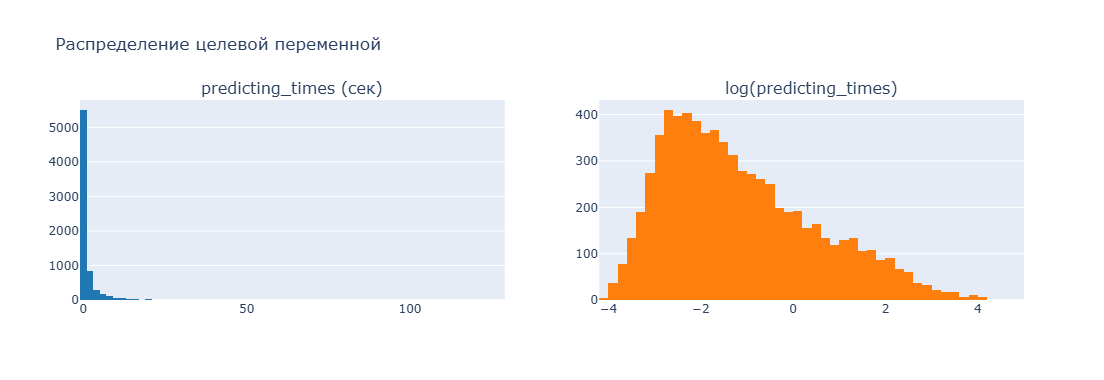

In [102]:
# Распределение таргета до/после log
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('predicting_times (сек)', 'log(predicting_times)'))
fig.add_trace(go.Histogram(x=df['predicting_times'], nbinsx=80, marker_color='#1f77b4'), row=1, col=1)
fig.add_trace(go.Histogram(x=df['log_time'],         nbinsx=80, marker_color='#ff7f0e'), row=1, col=2)
fig.update_layout(title='Распределение целевой переменной', showlegend=False, height=380)
fig.show()

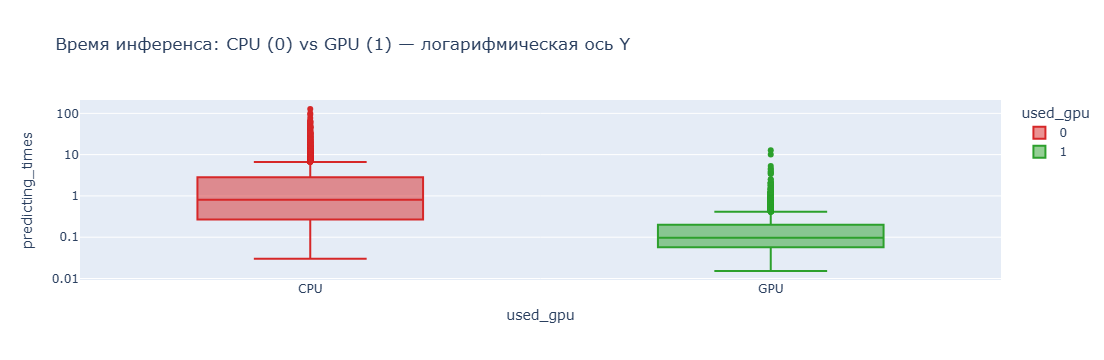

In [103]:
# Время по устройствам (log Y — разница на порядки)
fig = px.box(df, x='used_gpu', y='predicting_times', log_y=True, points='outliers',
             title='Время инференса: CPU (0) vs GPU (1) — логарифмическая ось Y',
             color='used_gpu', color_discrete_map={0: '#d62728', 1: '#2ca02c'})
fig.update_xaxes(tickvals=[0, 1], ticktext=['CPU', 'GPU'])
fig.show()

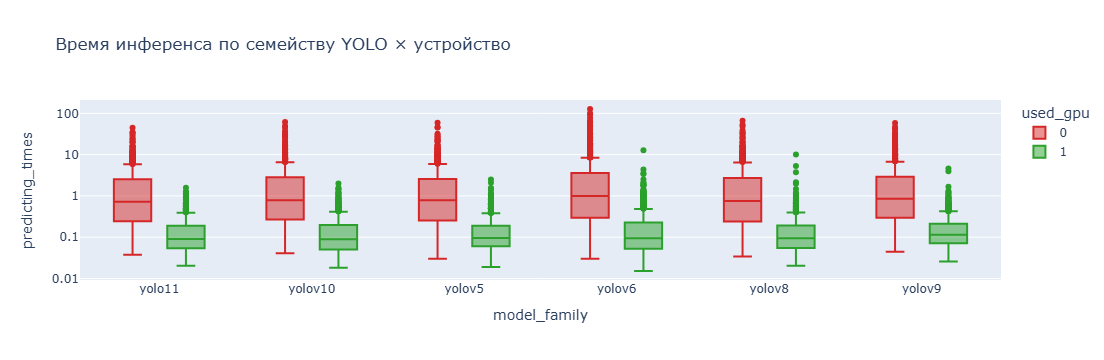

In [104]:
# Время по семейству моделей × устройство
order = sorted(df['model_family'].dropna().unique())
fig = px.box(df, x='model_family', y='predicting_times', color='used_gpu',
             log_y=True, title='Время инференса по семейству YOLO × устройство',
             category_orders={'model_family': order},
             color_discrete_map={0: '#d62728', 1: '#2ca02c'})
fig.show()

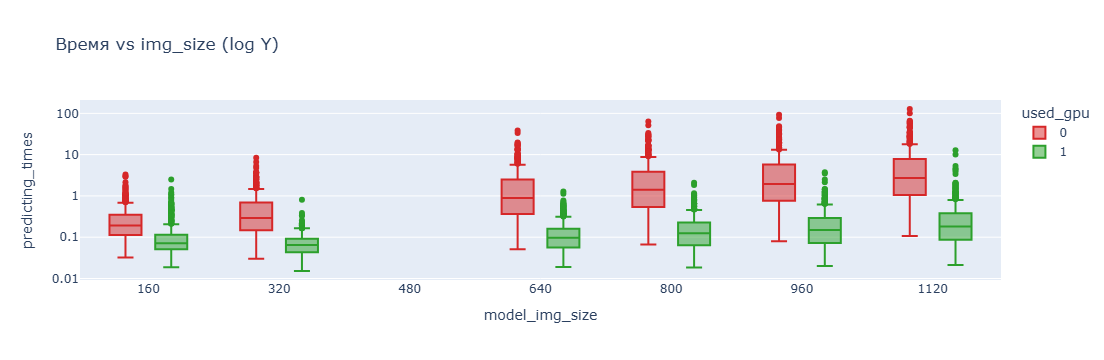

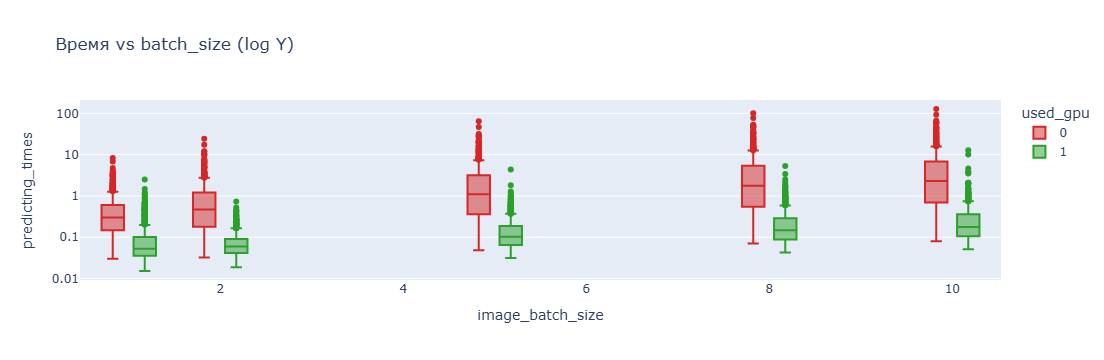

In [105]:
# Время по img_size и batch_size
fig = px.box(df, x='model_img_size', y='predicting_times', color='used_gpu',
             log_y=True, title='Время vs img_size (log Y)',
             color_discrete_map={0: '#d62728', 1: '#2ca02c'})
fig.show()

fig = px.box(df, x='image_batch_size', y='predicting_times', color='used_gpu',
             log_y=True, title='Время vs batch_size (log Y)',
             color_discrete_map={0: '#d62728', 1: '#2ca02c'})
fig.show()

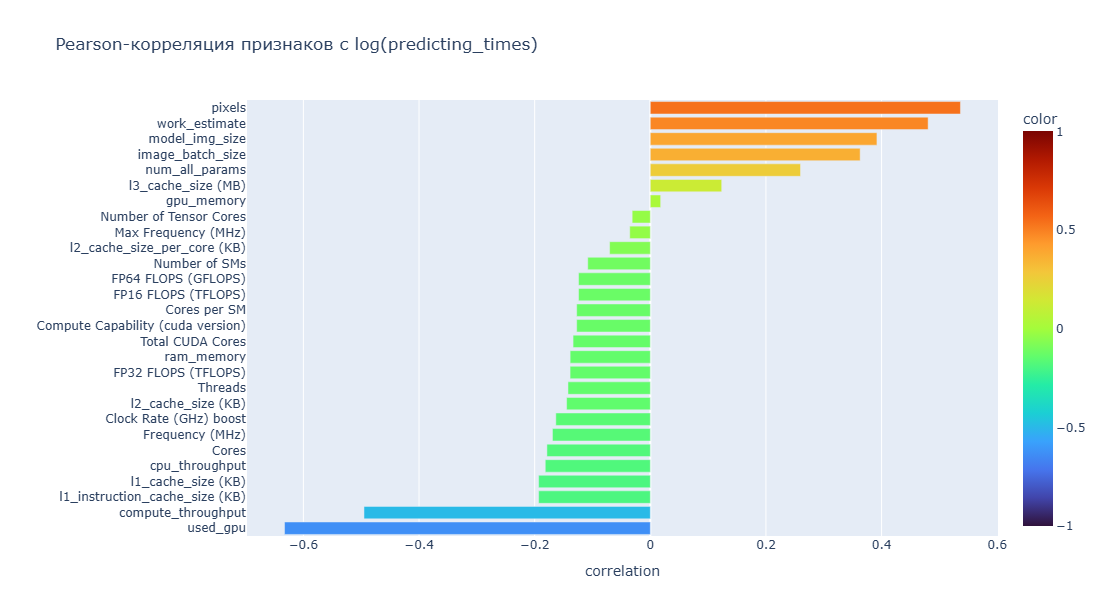

In [106]:
# Корреляция numeric-фич с log_time
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ('predicting_times', 'log_time')]
corr = df[num_cols + ['log_time']].corr()['log_time'].drop('log_time').sort_values()

fig = px.bar(x=corr.values, y=corr.index, orientation='h',
             title='Pearson-корреляция признаков с log(predicting_times)',
             labels={'x': 'correlation', 'y': ''},
             color=corr.values, color_continuous_scale='Turbo',
             range_color=[-1, 1])
fig.update_layout(height=max(500, 22 * len(corr)))
fig.show()

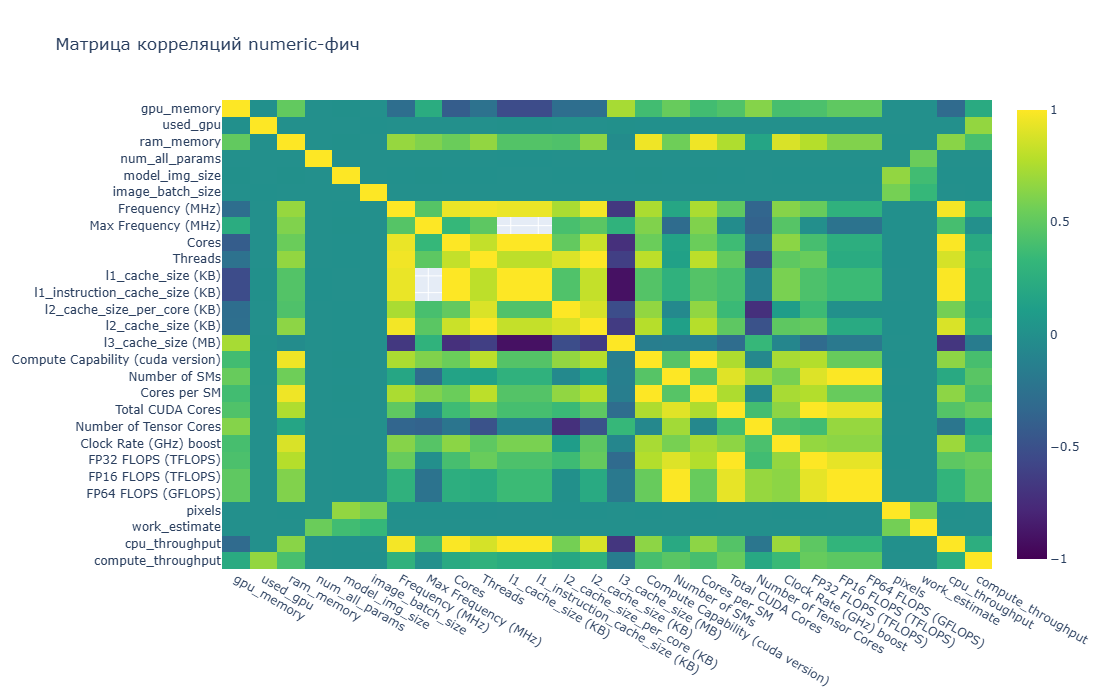

In [123]:
# Полная heatmap корреляций
fig = px.imshow(df[num_cols].corr(), aspect='auto',
                color_continuous_scale='Viridis', zmin=-1, zmax=1,
                title='Матрица корреляций numeric-фич')
fig.update_layout(height=700)
fig.show()

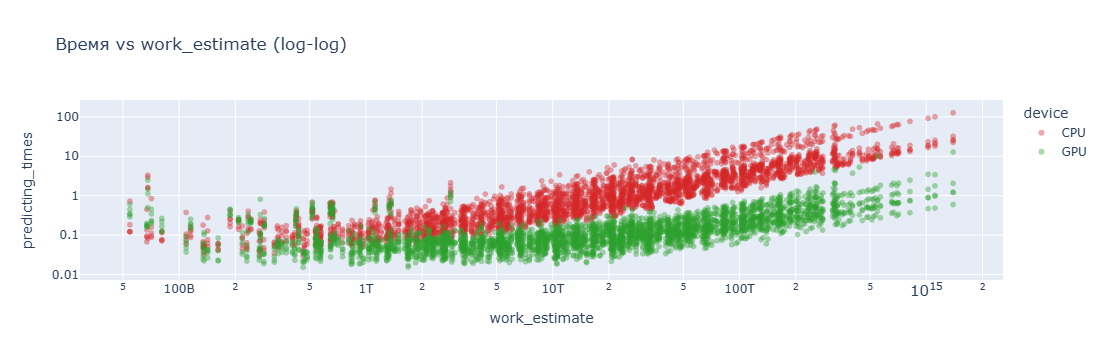

In [108]:
# Scatter: work_estimate vs predicting_times в log-log
fig = px.scatter(df, x='work_estimate', y='predicting_times',
                 color=df['used_gpu'].map({0: 'CPU', 1: 'GPU'}),
                 log_x=True, log_y=True, opacity=0.4,
                 title='Время vs work_estimate (log-log)',
                 labels={'color': 'device'},
                 color_discrete_map={'CPU': '#d62728', 'GPU': '#2ca02c'})
fig.show()

## 4. Фичи, таргет, группы для CV

In [109]:
CATEGORICAL = ['cpu_name', 'gpu_name', 'model_name', 'model_family']

DROP_FROM_FEATURES = {
    'predicting_times',  # original target
    'log_time',          # log target
}

FEATURES = [c for c in df.columns if c not in DROP_FROM_FEATURES]
NUMERIC  = [c for c in FEATURES if c not in CATEGORICAL]

X = df[FEATURES].copy()
y = df['log_time'].copy()

# Группировка для GroupKFold — CV не должна показывать модели одно и то же железо
groups = (df['cpu_name'].astype(str) + ' | ' + df['gpu_name'].astype(str)).values
print('уникальных групп (cpu × gpu):', len(set(groups)))
print('фич:', len(FEATURES), '| numeric:', len(NUMERIC), '| categorical:', len(CATEGORICAL))

уникальных групп (cpu × gpu): 5
фич: 33 | numeric: 29 | categorical: 4


## 5. Модели и CV

- **Tree-модели** (CatBoost, LightGBM, XGBoost) — получают X с `category` dtype у категориальных, NaN обрабатывают нативно.
- **RF / KNN / LinearRegression** — идут через Pipeline `ColumnTransformer(OHE + StandardScaler + SimpleImputer)`.
- **Метрики:** RMSE/MAE/R² в log-пространстве + MAE в секундах (после `exp`).
- **CV:** `GroupKFold(n_splits=5)` по паре (cpu, gpu) — честно мерит обобщение на новое железо.

In [110]:
def make_tree_X(X_in):
    """Копия с category dtype у cat-колонок — для LGBM/XGB/CatBoost."""
    X_tree = X_in.copy()
    for c in CATEGORICAL:
        X_tree[c] = X_tree[c].astype('category')
    return X_tree

def _make_ohe():
    """Совместимо с sklearn <1.2 (sparse=) и >=1.2 (sparse_output=)."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def make_sklearn_pipeline(estimator):
    """Pipeline для моделей, чувствительных к масштабу и не поддерживающих категориальные из коробки."""
    numeric_tf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    pre = ColumnTransformer([
        ('num', numeric_tf, NUMERIC),
        ('cat', _make_ohe(), CATEGORICAL),
    ])
    return Pipeline([('pre', pre), ('model', estimator)])

def build_models():
    return {
        'CatBoost':       cb.CatBoostRegressor(iterations=600, depth=8, learning_rate=0.05,
                                                cat_features=CATEGORICAL, verbose=0,
                                                random_seed=RANDOM_STATE),
        'LightGBM':       lgb.LGBMRegressor(n_estimators=600, num_leaves=63, learning_rate=0.05,
                                             random_state=RANDOM_STATE, verbose=-1),
        'XGBoost':        xgb.XGBRegressor(n_estimators=600, max_depth=8, learning_rate=0.05,
                                            tree_method='hist', enable_categorical=True,
                                            random_state=RANDOM_STATE, verbosity=0),
        'RandomForest':   make_sklearn_pipeline(RandomForestRegressor(
                              n_estimators=400, max_depth=None, n_jobs=-1,
                              random_state=RANDOM_STATE)),
        'KNN':            make_sklearn_pipeline(KNeighborsRegressor(n_neighbors=7, weights='distance')),
        # OLS без регуляризации разваливается от мультиколлинеарности (work_estimate ≈ num_params×pixels,
        # Total CUDA Cores ≈ SMs×Cores per SM, и т.п.). Ridge с L2 делает матрицу обусловленной.
        'LinearRegression': make_sklearn_pipeline(Ridge(alpha=1.0, solver='svd')),
    }

In [111]:
def cv_evaluate(model_name, model, X_in, y_in, groups_in, n_splits=5):
    is_tree = model_name in {'CatBoost', 'LightGBM', 'XGBoost'}
    X_use = make_tree_X(X_in) if is_tree else X_in

    rmse_log, mae_log, r2_log, mae_sec, mape = [], [], [], [], []
    gkf = GroupKFold(n_splits=n_splits)
    for tr, va in gkf.split(X_use, y_in, groups=groups_in):
        Xt, Xv = X_use.iloc[tr], X_use.iloc[va]
        yt, yv = y_in.iloc[tr], y_in.iloc[va]
        # tree models: fresh instance every fold чтобы не накапливать state
        est = build_models()[model_name] if is_tree else model
        est.fit(Xt, yt)
        pred = est.predict(Xv)

        # log-space метрики устойчивы к выбросам
        rmse_log.append(np.sqrt(mean_squared_error(yv, pred)))
        mae_log.append(mean_absolute_error(yv, pred))
        r2_log.append(r2_score(yv, pred))

        # для exp-метрик клипим pred к диапазону таргета +- 2 nat,
        # иначе LinearRegression на unseen группах улетает в inf после exp
        lo, hi = yt.min() - 2.0, yt.max() + 2.0
        pred_c = np.clip(pred, lo, hi)
        yv_s, pr_s = np.exp(yv), np.exp(pred_c)
        mae_sec.append(mean_absolute_error(yv_s, pr_s))
        mape.append(float(np.mean(np.abs((yv_s - pr_s) / yv_s)) * 100))

    return {
        'model': model_name,
        'RMSE (log)': float(np.mean(rmse_log)),
        'MAE (log)':  float(np.mean(mae_log)),
        'R² (log)':   float(np.mean(r2_log)),
        'MAE (сек)':  float(np.mean(mae_sec)),
        'MAPE (%)':   float(np.mean(mape)),
    }

def compare_models(X_in, y_in, groups_in, label='all'):
    rows = []
    for name, model in build_models().items():
        print(f'  [{label}] {name} ...', end=' ', flush=True)
        res = cv_evaluate(name, model, X_in, y_in, groups_in)
        rows.append(res)
        print(f'R²={res["R² (log)"]:.3f}  MAPE={res["MAPE (%)"]:.1f}%')
    return pd.DataFrame(rows).sort_values('R² (log)', ascending=False).reset_index(drop=True)

In [112]:
print('=== Унифицированная модель (обе device) ===')
results_all = compare_models(X, y, groups, label='all')
results_all

=== Унифицированная модель (обе device) ===
  [all] CatBoost ... R²=0.907  MAPE=38.8%
  [all] LightGBM ... R²=0.891  MAPE=32.7%
  [all] XGBoost ... R²=0.891  MAPE=43.4%
  [all] RandomForest ... R²=0.907  MAPE=40.2%
  [all] KNN ... R²=0.841  MAPE=49.9%
  [all] LinearRegression ... R²=0.806  MAPE=54.4%


,model,RMSE (log),MAE (log),R² (log),MAE (сек),MAPE (%)
0,CatBoost,0.479997,0.377982,0.907394,0.752693,38.769876
1,RandomForest,0.477606,0.385038,0.907152,0.722240,40.212390
2,LightGBM,0.504055,0.400516,0.890846,0.712604,32.699637
3,XGBoost,0.530350,0.424227,0.890726,0.707139,43.388643
4,KNN,0.635626,0.498695,0.841087,0.785442,49.882402
5,LinearRegression,0.703270,0.534477,0.806225,0.843418,54.398705


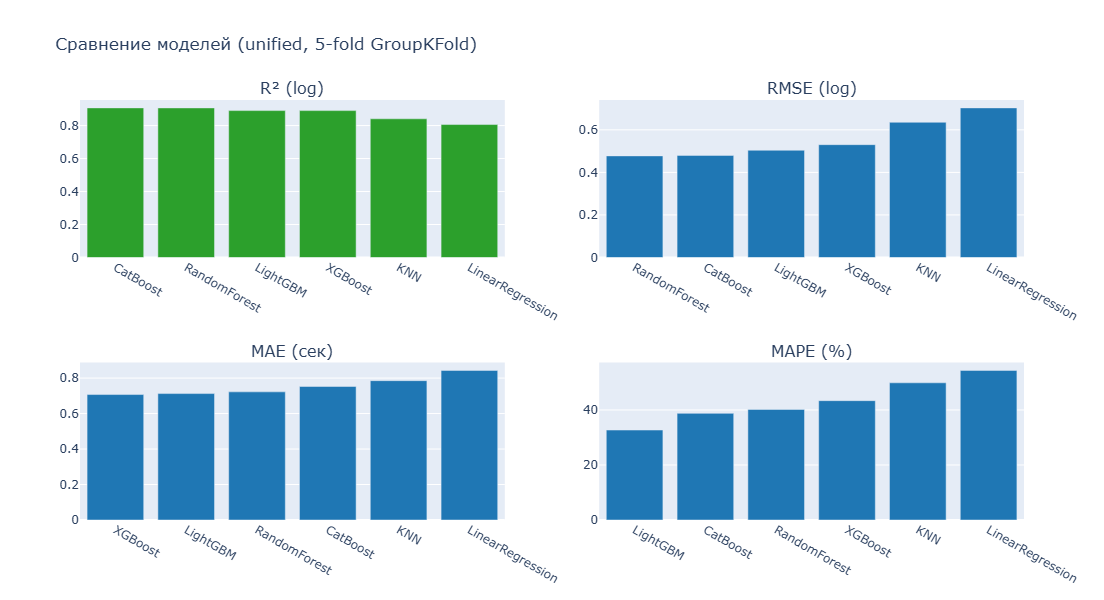

In [113]:
# Визуализация сравнения
metrics_plot = ['R² (log)', 'RMSE (log)', 'MAE (сек)', 'MAPE (%)']
fig = make_subplots(rows=2, cols=2, subplot_titles=metrics_plot)
for i, m in enumerate(metrics_plot):
    r, c = i // 2 + 1, i % 2 + 1
    sorted_df = results_all.sort_values(m, ascending=(m != 'R² (log)'))
    fig.add_trace(go.Bar(x=sorted_df['model'], y=sorted_df[m], name=m,
                          marker_color='#2ca02c' if m == 'R² (log)' else '#1f77b4'),
                  row=r, col=c)
fig.update_layout(title='Сравнение моделей (unified, 5-fold GroupKFold)', showlegend=False, height=600)
fig.show()

## 6. Feature importance (tree-модели)

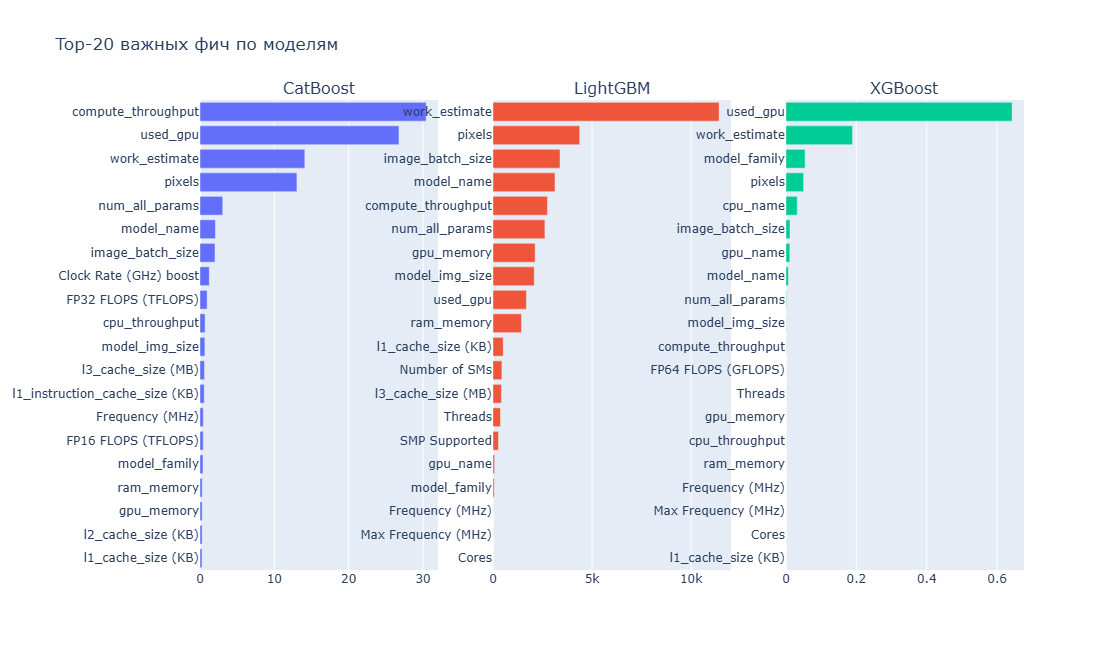

In [114]:
X_tree = make_tree_X(X)

cbr = build_models()['CatBoost'].fit(X_tree, y)
lgbm = build_models()['LightGBM'].fit(X_tree, y)
xgbr = build_models()['XGBoost'].fit(X_tree, y)

def importance_df(model, feature_names, kind):
    if kind == 'catboost':
        imp = model.get_feature_importance()
    elif kind == 'lightgbm':
        imp = model.feature_importances_
    else:  # xgboost
        imp = model.feature_importances_
    return (pd.DataFrame({'feature': feature_names, 'importance': imp})
              .sort_values('importance', ascending=True)
              .tail(20))

fig = make_subplots(rows=1, cols=3, subplot_titles=('CatBoost', 'LightGBM', 'XGBoost'),
                    shared_yaxes=False)
for i, (m, kind) in enumerate([(cbr, 'catboost'), (lgbm, 'lightgbm'), (xgbr, 'xgboost')]):
    d = importance_df(m, X_tree.columns.tolist(), kind)
    fig.add_trace(go.Bar(x=d['importance'], y=d['feature'], orientation='h'), row=1, col=i+1)
fig.update_layout(title='Top-20 важных фич по моделям', height=650, showlegend=False)
fig.show()

## 7. Сравнение предсказаний на held-out сплите

Берём group-aware train/test (новое железо в test → честная оценка), предсказываем, строим:
1. Box-plot residuals (секунды) по моделям.
2. Scatter predicted vs actual в log-log для топ-2 моделей.
3. Для 15 случайных наблюдений — bar-chart с предсказанием каждой модели и истинным значением.

In [115]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[tr_idx].reset_index(drop=True), X.iloc[te_idx].reset_index(drop=True)
y_train, y_test = y.iloc[tr_idx].reset_index(drop=True), y.iloc[te_idx].reset_index(drop=True)
print('train:', X_train.shape, '| test:', X_test.shape)

X_train_tree = make_tree_X(X_train)
X_test_tree  = make_tree_X(X_test)

# клип к диапазону train-таргета ± 2 nat чтобы exp не улетал
CLIP_LO, CLIP_HI = y_train.min() - 2.0, y_train.max() + 2.0

predictions = {}
for name, model in build_models().items():
    is_tree = name in {'CatBoost', 'LightGBM', 'XGBoost'}
    Xt, Xv = (X_train_tree, X_test_tree) if is_tree else (X_train, X_test)
    model.fit(Xt, y_train)
    predictions[name] = np.clip(model.predict(Xv), CLIP_LO, CLIP_HI)
    print(f'{name}: ok')

train: (5760, 33) | test: (1440, 33)
CatBoost: ok
LightGBM: ok
XGBoost: ok
RandomForest: ok
KNN: ok
LinearRegression: ok


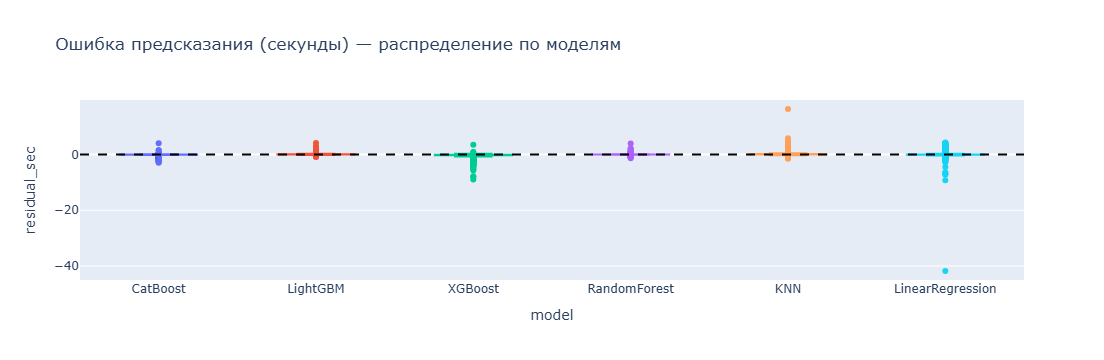

In [116]:
# Residuals в секундах — длинный формат для plotly
rows = []
y_test_sec = np.exp(y_test)
for name, pred in predictions.items():
    resid = y_test_sec - np.exp(pred)
    rows.append(pd.DataFrame({'model': name, 'residual_sec': resid}))
resid_df = pd.concat(rows, ignore_index=True)

fig = px.box(resid_df, x='model', y='residual_sec',
             points='outliers', title='Ошибка предсказания (секунды) — распределение по моделям',
             color='model')
fig.add_hline(y=0, line_dash='dash', line_color='black')
fig.update_layout(showlegend=False)
fig.show()

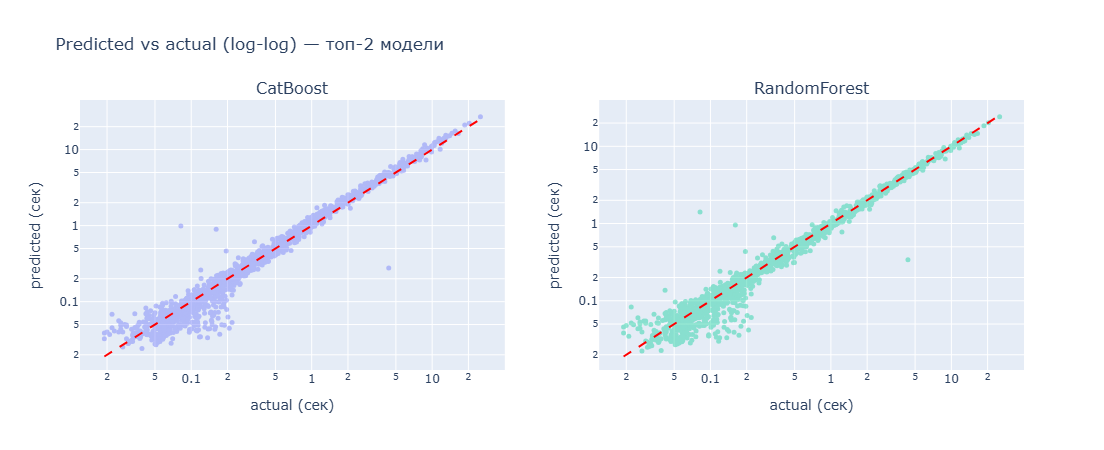

In [117]:
# Predicted vs actual (log-log) — топ-2 по R²
top2 = results_all.head(2)['model'].tolist()
fig = make_subplots(rows=1, cols=2, subplot_titles=top2)
for i, name in enumerate(top2, start=1):
    fig.add_trace(go.Scatter(x=np.exp(y_test), y=np.exp(predictions[name]),
                              mode='markers', opacity=0.4,
                              marker=dict(size=5)),
                  row=1, col=i)
    lims = [np.exp(y_test).min(), np.exp(y_test).max()]
    fig.add_trace(go.Scatter(x=lims, y=lims, mode='lines',
                              line=dict(dash='dash', color='red')), row=1, col=i)
    fig.update_xaxes(type='log', title='actual (сек)', row=1, col=i)
    fig.update_yaxes(type='log', title='predicted (сек)', row=1, col=i)
fig.update_layout(title='Predicted vs actual (log-log) — топ-2 модели', showlegend=False, height=450)
fig.show()

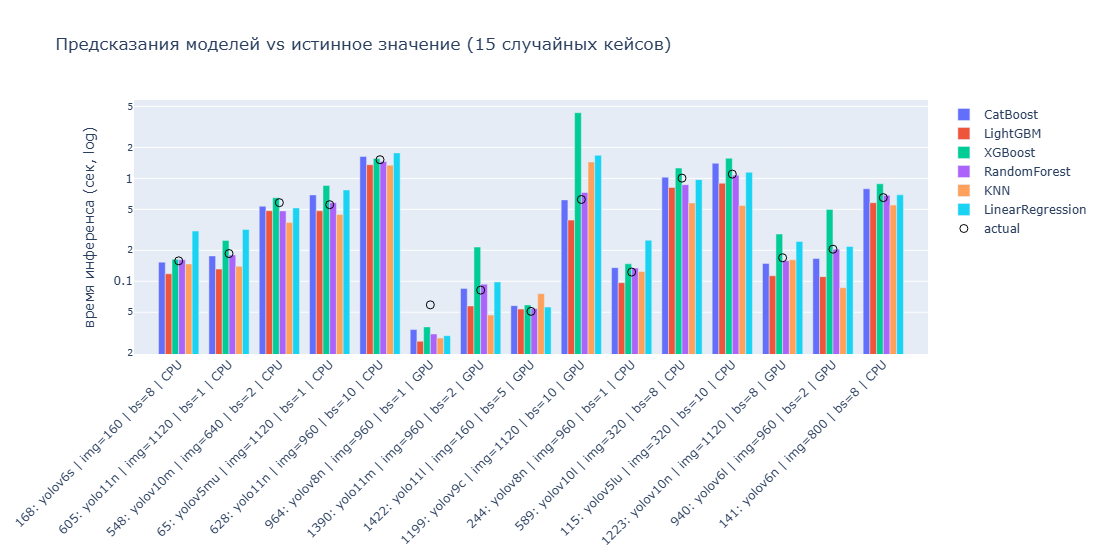

In [118]:
# 15 случайных наблюдений: предсказание каждой модели vs ground truth
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=15, replace=False)
labels = [f"{i}: {X_test.iloc[i]['model_name'].replace('.pt','').replace('.yaml','')}"
          f" | img={int(X_test.iloc[i]['model_img_size'])}"
          f" | bs={int(X_test.iloc[i]['image_batch_size'])}"
          f" | {'GPU' if X_test.iloc[i]['used_gpu'] else 'CPU'}"
          for i in sample_idx]

fig = go.Figure()
for name, pred in predictions.items():
    fig.add_trace(go.Bar(name=name, x=labels, y=np.exp(pred[sample_idx])))
fig.add_trace(go.Scatter(name='actual', x=labels, y=np.exp(y_test.values[sample_idx]),
                          mode='markers', marker=dict(color='black', size=8, symbol='circle-open')))
fig.update_layout(barmode='group', title='Предсказания моделей vs истинное значение (15 случайных кейсов)',
                   yaxis_type='log', yaxis_title='время инференса (сек, log)',
                   xaxis_tickangle=-45, height=560)
fig.show()

## 8. Сплит по устройствам: одна модель vs две

Гипотеза: GPU и CPU — разные режимы (FLOPs-bound vs cache/cores-bound), одна модель может страдать. Проверяем обучением на подмножестве `used_gpu == 0` / `used_gpu == 1` и сравнением с общей моделью на том же подмножестве.

In [119]:
results_parts = {}
for part, mask in [('gpu', df['used_gpu'] == 1), ('cpu', df['used_gpu'] == 0)]:
    print(f'\n=== Специализированная модель: {part.upper()} ({mask.sum()} строк) ===')
    Xp = X[mask].reset_index(drop=True)
    yp = y[mask].reset_index(drop=True)
    gp = groups[mask.values]
    results_parts[part] = compare_models(Xp, yp, gp, label=part)

results_parts['gpu']


=== Специализированная модель: GPU (3600 строк) ===
  [gpu] CatBoost ... R²=0.731  MAPE=36.2%
  [gpu] LightGBM ... R²=0.652  MAPE=35.5%
  [gpu] XGBoost ... R²=0.565  MAPE=48.3%
  [gpu] RandomForest ... R²=0.753  MAPE=34.8%
  [gpu] KNN ... R²=0.403  MAPE=57.3%
  [gpu] LinearRegression ... R²=0.519  MAPE=46.6%

=== Специализированная модель: CPU (3600 строк) ===
  [cpu] CatBoost ... R²=0.877  MAPE=35.5%
  [cpu] LightGBM ... R²=0.866  MAPE=33.8%
  [cpu] XGBoost ... R²=0.818  MAPE=52.7%
  [cpu] RandomForest ... R²=0.886  MAPE=32.0%
  [cpu] KNN ... R²=0.843  MAPE=41.7%
  [cpu] LinearRegression ... R²=0.867  MAPE=41.2%


,model,RMSE (log),MAE (log),R² (log),MAE (сек),MAPE (%)
0,RandomForest,0.434725,0.358040,0.753187,0.081759,34.766319
1,CatBoost,0.448466,0.375556,0.730846,0.084598,36.247574
2,LightGBM,0.493547,0.416702,0.652185,0.095403,35.477459
3,XGBoost,0.565628,0.467498,0.565008,0.099729,48.265540
4,LinearRegression,0.596040,0.449573,0.518866,0.096623,46.553453
5,KNN,0.665199,0.546714,0.403388,0.121102,57.259437


In [120]:
results_parts['cpu']

,model,RMSE (log),MAE (log),R² (log),MAE (сек),MAPE (%)
0,RandomForest,0.444964,0.376547,0.886328,1.330109,32.008621
1,CatBoost,0.471634,0.392364,0.877357,1.362335,35.472602
2,LinearRegression,0.532176,0.420600,0.866989,1.483999,41.200391
3,LightGBM,0.489843,0.421854,0.866443,1.347461,33.833955
4,KNN,0.568548,0.461590,0.842668,1.386600,41.733205
5,XGBoost,0.581551,0.489244,0.817840,1.406014,52.742455


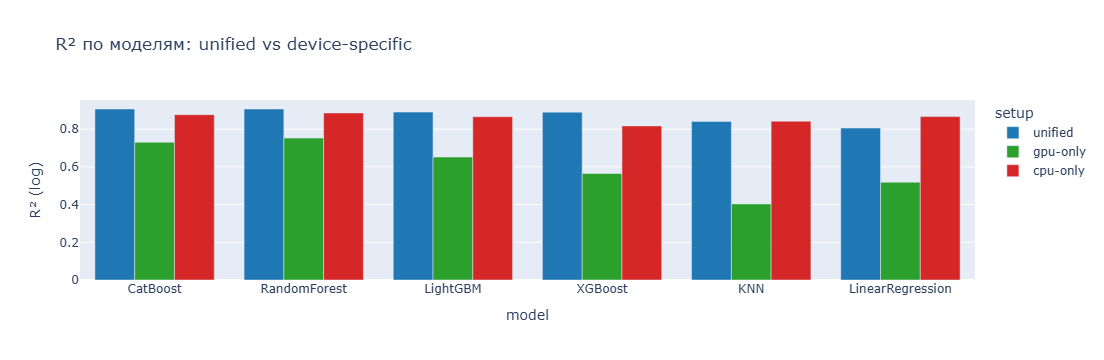

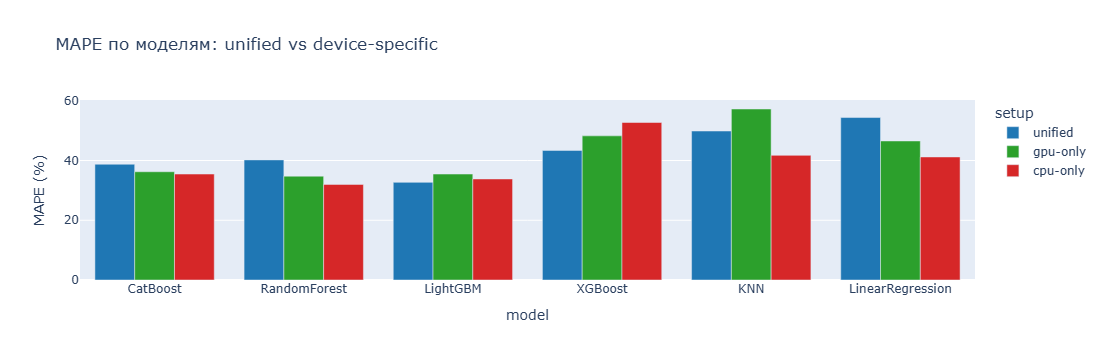

In [121]:
# Сравнение unified vs split по R² и MAPE
def with_label(df_in, lab):
    out = df_in.copy()
    out['setup'] = lab
    return out

combined = pd.concat([
    with_label(results_all,       'unified'),
    with_label(results_parts['gpu'], 'gpu-only'),
    with_label(results_parts['cpu'], 'cpu-only'),
], ignore_index=True)

fig = px.bar(combined, x='model', y='R² (log)', color='setup', barmode='group',
             title='R² по моделям: unified vs device-specific',
             color_discrete_sequence=['#1f77b4', '#2ca02c', '#d62728'])
fig.show()

fig = px.bar(combined, x='model', y='MAPE (%)', color='setup', barmode='group',
             title='MAPE по моделям: unified vs device-specific',
             color_discrete_sequence=['#1f77b4', '#2ca02c', '#d62728'])
fig.show()

## 9. Выводы

Итоги на 7200 наблюдений (4 CPU × 5 GPU × 24 варианта YOLO × 6 img_size × 5 batch), `GroupKFold(5)` по паре `(cpu, gpu)`.

### Итоговая таблица

| Setup | Лучшая модель | R² (log) | MAPE |
|---|---|---|---|
| unified (обе device) | CatBoost ≈ RandomForest | **0.907** | 38.8% / 40.2% |
| только GPU | RandomForest | 0.753 | 34.8% |
| только CPU | RandomForest | 0.886 | 32.0% |
| лучший MAPE unified | LightGBM | 0.891 | **32.7%** |

### Ключевые наблюдения

- **Unified модель выигрывает у специализированных.** На GPU-подмножестве R² падает с 0.91 до 0.75. Это контр-интуитивно, но объяснимо: tree-методы видят оба режима и сами делают первое разбиение по `used_gpu`, после чего внутри каждой ветки получают **больше** примеров для обучения, чем если бы мы держали модели отдельно. Split имеет смысл только при большом объёме данных **в каждом** режиме — у нас их по 3600, и это мало для честного GroupKFold на GPU (5 групп → 1 группа в test = 20% железа невиданного).
- **RandomForest неожиданно на одном уровне с CatBoost** (R² = 0.907 у обоих на unified, RF чуть лучше на сплитах). На таком скромном датасете бустинг не успевает раскрыться; RF — проще, быстрее в инференсе, и по качеству здесь не уступает.
- **LightGBM лучший по MAPE** (32.7% vs 38.8% у CatBoost). Если для прода критична относительная ошибка — брать LightGBM.
- **LinearRegression (Ridge) неожиданно хорош на CPU-only** (R² = 0.867, почти как бустинги). CPU-инференс действительно почти линейно масштабируется по `cores × freq × work_estimate`; на GPU зависимость сложнее (плато kernel-launch, tensor-cores), там Ridge теряет до 0.52.
- **XGBoost и KNN проседают на GPU-сплите** (0.565 и 0.403). XGB тут неустойчив к малой выборке + native categorical на 3600 строк; KNN страдает от высокой размерности OHE.
- **GPU-подмножество сложнее, чем CPU.** Разница R² (0.75 vs 0.89) — это плата за нелинейности GPU-инференса: kernel-launch latency на маленьких батчах, резкие переходы между memory-bound и compute-bound режимами, эффекты tensor cores.
- **Ограничение датасета — всего 5 уникальных пар `(cpu, gpu)`.** GroupKFold жёсткий: каждый фолд оценивает экстраполяцию на новое железо, для большей уверенности хорошо было бы собрать данные с ещё 5–10 платформ.